In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import requests
import io
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
url = 'https://en.wikipedia.org/wiki/NIFTY_50#Constituents'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

In [ ]:
nifty50_df = tables[1]

In [4]:
nifty50_df['Sector[15]'].value_counts()

,count
Sector[15],
Financial Services,11
Automobile and Auto Components,5
Healthcare,5
Information Technology,5
Metals & Mining,4
Fast Moving Consumer Goods,4
"Oil, Gas & Consumable Fuels",3
Power,2
Consumer Durables,2


In [5]:
tickers = nifty50_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()

In [12]:
raw_data = yf.download(tickers_list, period='5y', interval='1wk')

/tmp/ipykernel_19240/3844561743.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers_list, period='5y', interval='1wk')
[*********************100%***********************]  50 of 50 completed


In [13]:
close_prices = raw_data['Close']

In [14]:
close_prices.describe()

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,...,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,26.000000,261.000000,261.000000,261.000000
mean,2407.877000,1022.029212,5558.903353,2824.567392,976.588515,6101.043837,1647.426680,736.355606,195.420621,1159.833267,...,1242.610150,916.854143,129.484359,3254.794159,1248.268005,2976.265962,359.384617,3087.466806,9015.530279,232.127494
std,646.414062,317.011228,1344.446411,327.332727,199.940630,2656.578327,251.805690,130.116993,129.408907,513.280202,...,408.597671,180.652233,30.264177,407.546429,253.007492,693.682770,29.715920,2070.968773,2248.247609,39.154226
min,1154.794922,491.012970,3021.493652,2156.457520,631.363892,2851.732422,980.269531,452.225220,39.601189,501.355316,...,607.201294,605.125183,76.639626,2389.800049,797.545837,1424.346191,303.200012,739.708862,5062.032227,169.191528
25%,1917.669434,723.460999,4404.530762,2549.617188,782.776245,3472.167480,1516.831055,658.065430,80.192535,721.552490,...,874.022644,747.965820,102.457253,2963.179932,1009.645081,2446.099121,345.349998,1239.998291,7086.060059,193.184662
50%,2361.629395,865.781311,5244.527832,2880.940918,992.435242,4963.348145,1632.823853,711.159607,134.830063,917.918152,...,1114.422119,878.487610,123.762123,3179.331299,1239.870117,3114.253662,355.474991,2081.567383,8328.059570,232.399994
75%,2913.066406,1344.900024,6879.095215,3085.111328,1154.000000,8715.969727,1819.013794,772.407349,295.703644,1627.296021,...,1667.245850,1099.760986,153.900940,3481.190430,1452.086304,3531.899902,379.687500,4960.302734,11292.420898,257.152435
max,4014.293457,1580.311523,7901.881836,3444.139648,1383.900024,12353.318359,2159.500000,1089.750000,466.464172,2162.699951,...,1918.210327,1243.694336,212.330002,4311.585449,1745.885742,4505.000000,410.000000,8227.822266,12963.000000,330.455627


In [15]:
close_prices = close_prices.dropna(axis=1)

In [16]:
log_returns = np.log(close_prices/close_prices.shift(1)).dropna()

In [17]:
log_returns.describe()

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,0.002271,0.002688,0.003503,-0.000296,0.002717,0.004336,0.002357,0.002750,0.009249,0.004932,...,0.005396,0.003808,0.002026,0.003814,-0.000411,0.002037,0.004165,0.006410,0.002204,-0.000217
std,0.072793,0.051095,0.037690,0.035045,0.034505,0.035068,0.037747,0.038105,0.043620,0.028669,...,0.045429,0.026885,0.031024,0.043819,0.030563,0.039081,0.034468,0.047989,0.033430,0.036141
min,-0.554036,-0.260320,-0.151708,-0.137232,-0.095923,-0.165640,-0.108632,-0.106080,-0.130615,-0.071193,...,-0.166435,-0.063837,-0.116475,-0.157167,-0.089079,-0.139800,-0.107003,-0.151555,-0.121460,-0.128909
25%,-0.023568,-0.022529,-0.015258,-0.017284,-0.015742,-0.015316,-0.020421,-0.020735,-0.016528,-0.013824,...,-0.016046,-0.014156,-0.016642,-0.019696,-0.016181,-0.019481,-0.017327,-0.018785,-0.015368,-0.021523
50%,0.001310,0.002161,0.004463,0.001618,0.002471,0.004237,0.001687,-0.000190,0.008525,0.005106,...,0.002510,0.002344,0.002532,0.003146,-0.000140,0.004639,0.007963,0.010544,0.002097,0.003113
75%,0.028611,0.030024,0.026723,0.021397,0.021530,0.019779,0.023892,0.022676,0.035001,0.023421,...,0.031402,0.019271,0.021608,0.029767,0.020446,0.024547,0.024865,0.034464,0.022095,0.023910
max,0.356675,0.211674,0.179677,0.106110,0.120127,0.113734,0.165354,0.155276,0.179810,0.101075,...,0.193498,0.109035,0.090464,0.139337,0.064014,0.114590,0.102514,0.184529,0.106355,0.126904


In [18]:
corr_matrix = log_returns.corr()

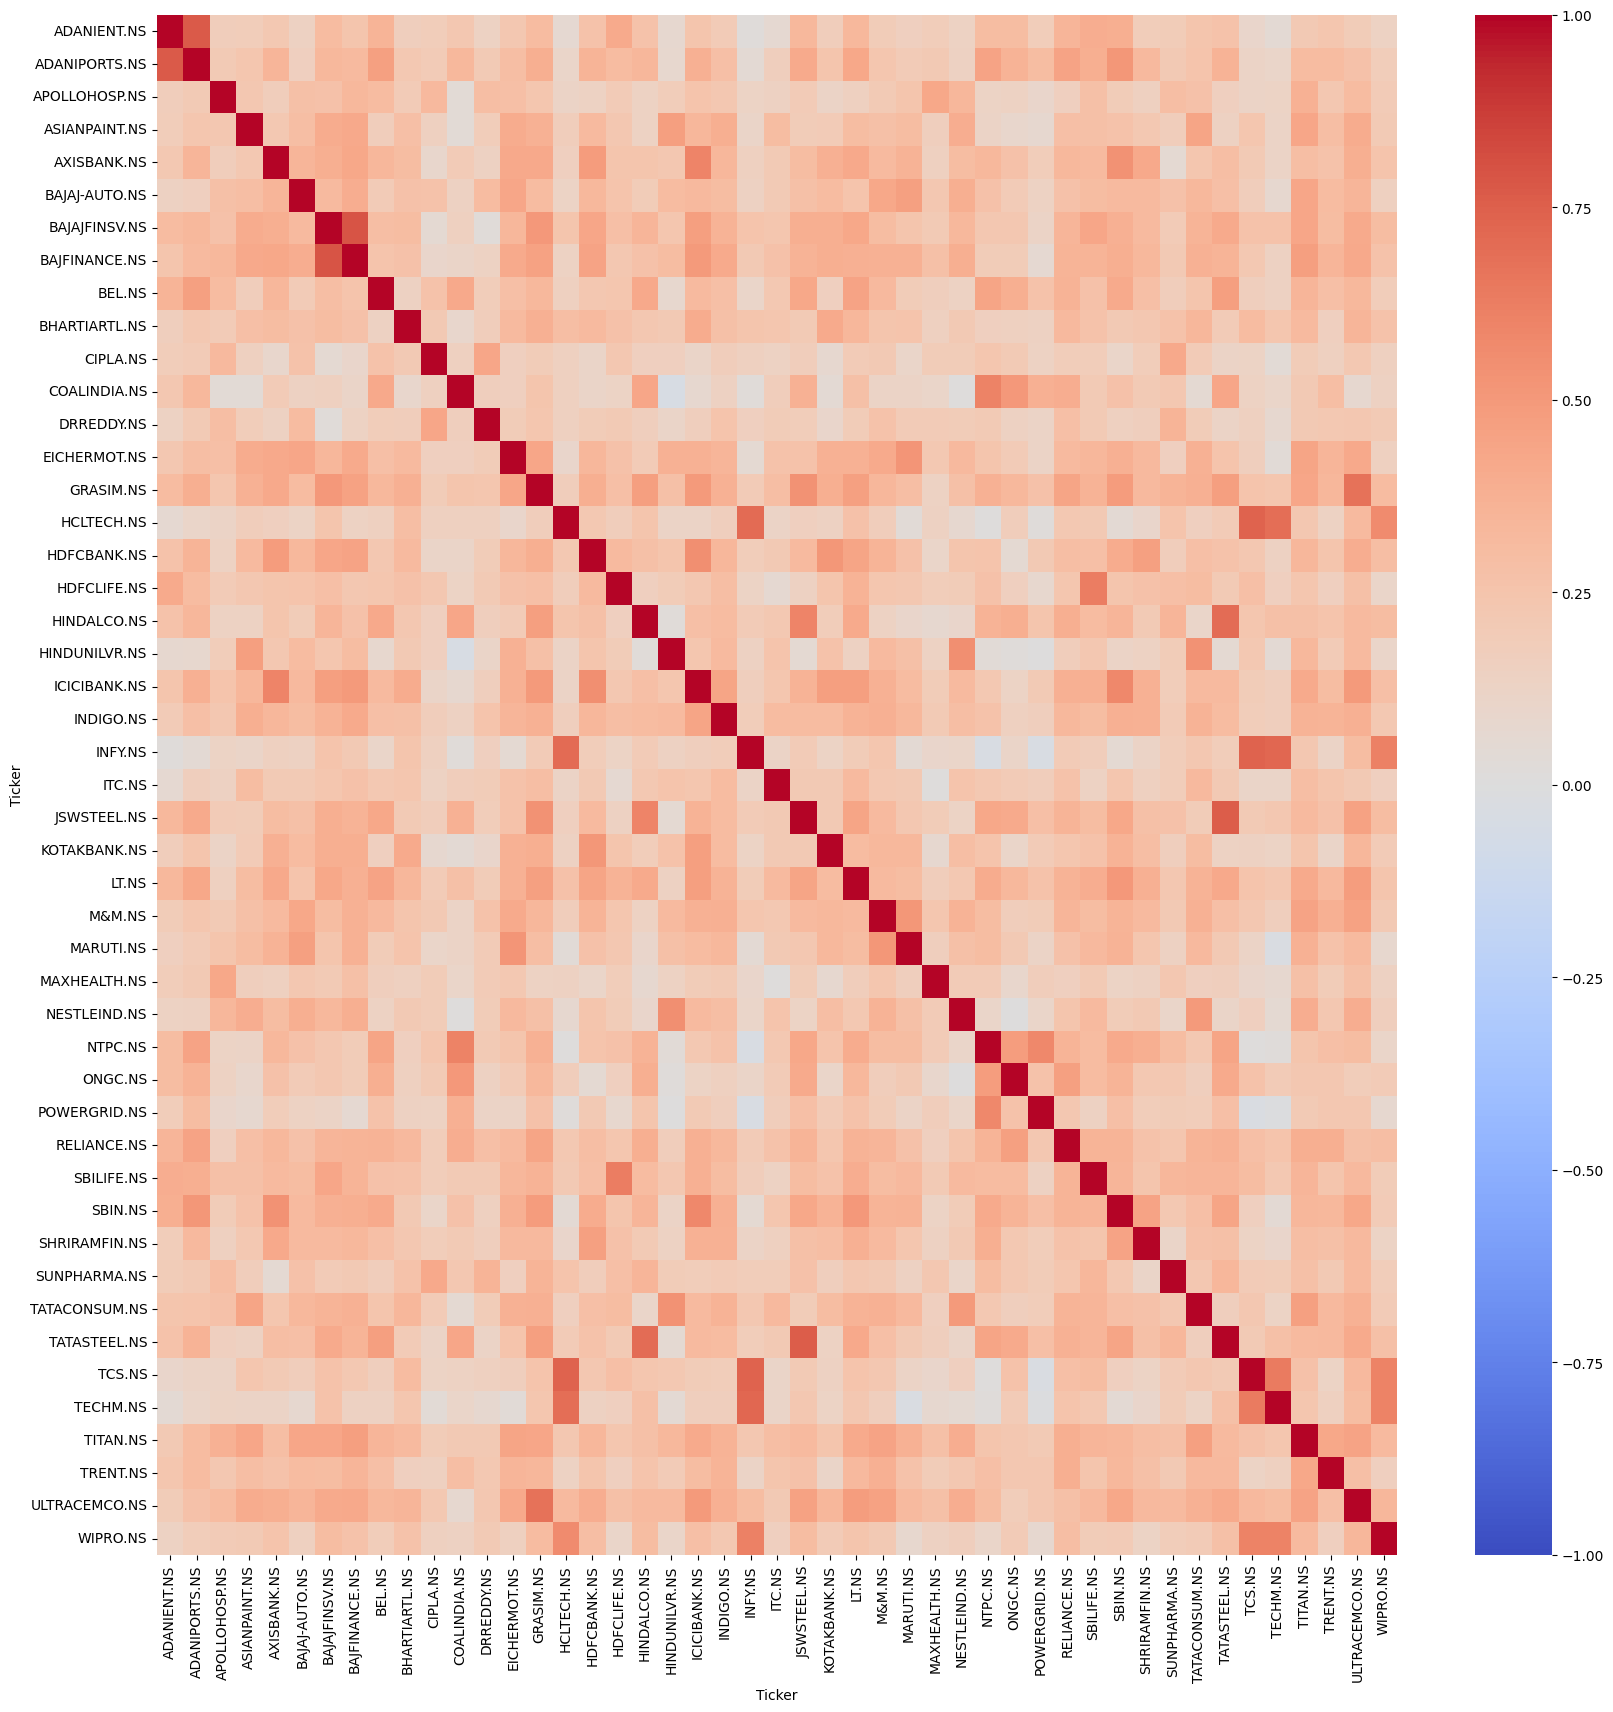

In [21]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [22]:
pca = PCA(n_components=10)

In [23]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [24]:
pca.explained_variance_

array([13.43503727,  3.40568278,  3.19714926,  2.06151388,  1.60056284,
        1.41106757,  1.35442019,  1.23928992,  1.1418491 ,  1.02578239])

In [25]:
pca.explained_variance_ratio_

array([0.28475243, 0.07218264, 0.06776282, 0.0436933 , 0.03392355,
       0.02990724, 0.02870661, 0.02626646, 0.02420122, 0.02174121])

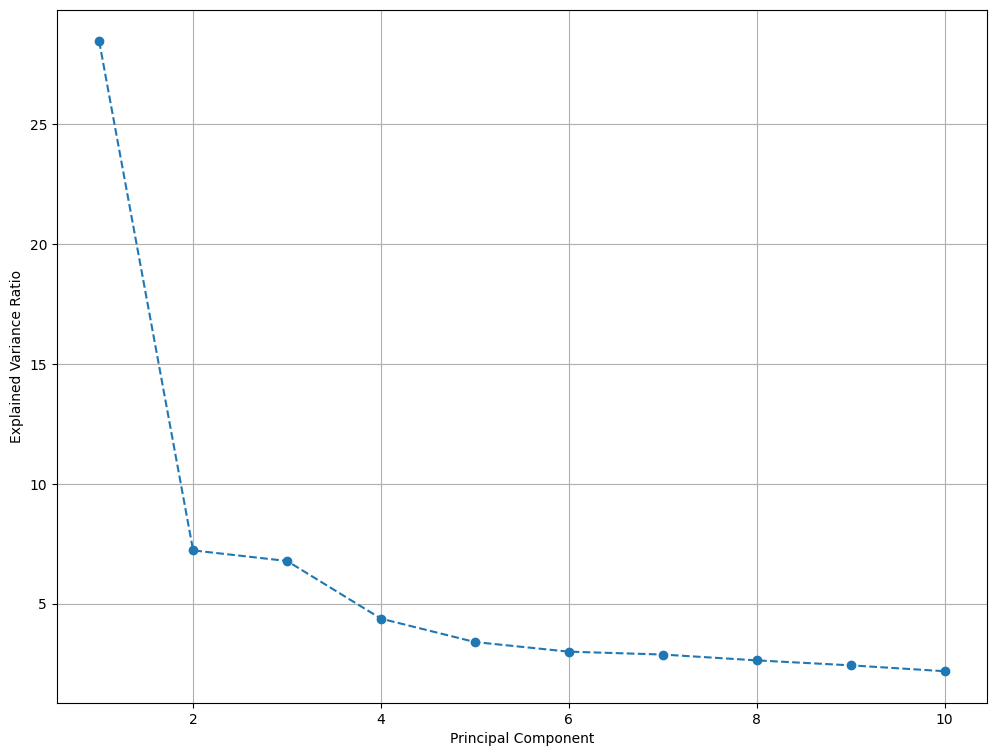

In [26]:
plt.figure(figsize=(12,9))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [27]:
industry_map = (
    nifty50_df[['Symbol', 'Sector[15]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[15]']
)

In [30]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
14,GRASIM.NS,19.586550,Construction Materials
45,ULTRACEMCO.NS,18.679515,Construction Materials
26,LT.NS,18.445295,Construction
20,ICICIBANK.NS,18.081288,Financial Services
43,TITAN.NS,17.953917,Consumer Durables
7,BAJFINANCE.NS,17.854873,Financial Services
6,BAJAJFINSV.NS,17.829429,Financial Services
36,SBIN.NS,17.675983,Financial Services
24,JSWSTEEL.NS,16.907200,Metals & Mining
34,RELIANCE.NS,16.862084,"Oil, Gas & Consumable Fuels"


,Ticker,Weight,Industry
23,ITC.NS,11.328259,Fast Moving Consumer Goods
19,HINDUNILVR.NS,11.003305,Fast Moving Consumer Goods
11,COALINDIA.NS,10.784322,"Oil, Gas & Consumable Fuels"
15,HCLTECH.NS,10.426835,Information Technology
12,DRREDDY.NS,10.217156,Healthcare
22,INFY.NS,9.999249,Information Technology
42,TECHM.NS,9.873061,Information Technology
33,POWERGRID.NS,9.846778,Power
29,MAXHEALTH.NS,9.470011,Healthcare
10,CIPLA.NS,9.405532,Healthcare


In [33]:
pc1_sorted

,Ticker,Weight,Industry
14,GRASIM.NS,19.586550,Construction Materials
45,ULTRACEMCO.NS,18.679515,Construction Materials
26,LT.NS,18.445295,Construction
20,ICICIBANK.NS,18.081288,Financial Services
43,TITAN.NS,17.953917,Consumer Durables
7,BAJFINANCE.NS,17.854873,Financial Services
6,BAJAJFINSV.NS,17.829429,Financial Services
36,SBIN.NS,17.675983,Financial Services
24,JSWSTEEL.NS,16.907200,Metals & Mining
34,RELIANCE.NS,16.862084,"Oil, Gas & Consumable Fuels"


In [31]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
22,INFY.NS,40.749591,Information Technology
15,HCLTECH.NS,37.509554,Information Technology
41,TCS.NS,37.047228,Information Technology
42,TECHM.NS,36.372171,Information Technology
46,WIPRO.NS,29.653870,Information Technology
19,HINDUNILVR.NS,10.583538,Fast Moving Consumer Goods
9,BHARTIARTL.NS,10.418359,Telecommunication
45,ULTRACEMCO.NS,7.585390,Construction Materials
3,ASIANPAINT.NS,6.820846,Consumer Durables
30,NESTLEIND.NS,6.020566,Fast Moving Consumer Goods


,Ticker,Weight,Industry
24,JSWSTEEL.NS,-9.050836,Metals & Mining
40,TATASTEEL.NS,-9.107708,Metals & Mining
32,ONGC.NS,-11.075345,"Oil, Gas & Consumable Fuels"
8,BEL.NS,-13.187893,Capital Goods
0,ADANIENT.NS,-14.961147,Metals & Mining
36,SBIN.NS,-15.965675,Financial Services
1,ADANIPORTS.NS,-17.527798,Services
11,COALINDIA.NS,-17.816882,"Oil, Gas & Consumable Fuels"
33,POWERGRID.NS,-19.765438,Power
31,NTPC.NS,-25.864806,Power


In [32]:
pc2_sorted

,Ticker,Weight,Industry
22,INFY.NS,40.749591,Information Technology
15,HCLTECH.NS,37.509554,Information Technology
41,TCS.NS,37.047228,Information Technology
42,TECHM.NS,36.372171,Information Technology
46,WIPRO.NS,29.653870,Information Technology
19,HINDUNILVR.NS,10.583538,Fast Moving Consumer Goods
9,BHARTIARTL.NS,10.418359,Telecommunication
45,ULTRACEMCO.NS,7.585390,Construction Materials
3,ASIANPAINT.NS,6.820846,Consumer Durables
30,NESTLEIND.NS,6.020566,Fast Moving Consumer Goods


In [34]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
11,COALINDIA.NS,28.290210,"Oil, Gas & Consumable Fuels"
18,HINDALCO.NS,26.273873,Metals & Mining
32,ONGC.NS,24.751275,"Oil, Gas & Consumable Fuels"
40,TATASTEEL.NS,23.555636,Metals & Mining
42,TECHM.NS,22.539691,Information Technology
24,JSWSTEEL.NS,19.947154,Metals & Mining
15,HCLTECH.NS,19.095579,Information Technology
31,NTPC.NS,15.933207,Power
46,WIPRO.NS,15.783806,Information Technology
22,INFY.NS,15.090041,Information Technology


,Ticker,Weight,Industry
27,M&M.NS,-12.272465,Automobile and Auto Components
25,KOTAKBANK.NS,-14.067097,Financial Services
7,BAJFINANCE.NS,-14.436121,Financial Services
5,BAJAJ-AUTO.NS,-15.149815,Automobile and Auto Components
13,EICHERMOT.NS,-18.055595,Automobile and Auto Components
28,MARUTI.NS,-18.515698,Automobile and Auto Components
39,TATACONSUM.NS,-18.930845,Fast Moving Consumer Goods
3,ASIANPAINT.NS,-19.993698,Consumer Durables
30,NESTLEIND.NS,-26.761745,Fast Moving Consumer Goods
19,HINDUNILVR.NS,-28.214160,Fast Moving Consumer Goods


In [35]:
pc3_sorted

,Ticker,Weight,Industry
11,COALINDIA.NS,28.290210,"Oil, Gas & Consumable Fuels"
18,HINDALCO.NS,26.273873,Metals & Mining
32,ONGC.NS,24.751275,"Oil, Gas & Consumable Fuels"
40,TATASTEEL.NS,23.555636,Metals & Mining
42,TECHM.NS,22.539691,Information Technology
24,JSWSTEEL.NS,19.947154,Metals & Mining
15,HCLTECH.NS,19.095579,Information Technology
31,NTPC.NS,15.933207,Power
46,WIPRO.NS,15.783806,Information Technology
22,INFY.NS,15.090041,Information Technology
